<a href="https://colab.research.google.com/github/traceswrldd/traceswrldd/blob/main/week_7_internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
%matplotlib inline

In [5]:
df = pd.read_csv('Diabetes_data.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (128, 11)

First 5 Rows:


,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,No
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,Yes
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,Yes
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,Yes
4,40,Male,20.0,Normal,80,5.0,No,No,Healthy,NaN,No


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())

# Handle missing values by dropping rows
df = df.dropna()


Missing Values:
Age                           0
Gender                        0
BMI                           3
Blood Pressure                0
FBS                           0
HbA1c                         0
Family History of Diabetes    2
Smoking                       2
Diet                          2
Exercise                      1
Diagnosis                     0
dtype: int64


In [7]:
# Check column names
print("\nColumn Names:")
print(df.columns)

# Preprocessing
# Identify categorical and numerical columns
categorical_cols = ['Gender', 'Blood Pressure', 'Family History of Diabetes', 'Smoking', 'Diet', 'Exercise']
numerical_cols = ['Age', 'BMI', 'FBS', 'HbA1c']

# Target column
target_column = 'Diagnosis'


Column Names:
Index(['Age', 'Gender', 'BMI', 'Blood Pressure', 'FBS', 'HbA1c',
       'Family History of Diabetes', 'Smoking', 'Diet', 'Exercise',
       'Diagnosis'],
      dtype='object')


In [8]:
# Create a ColumnTransformer to preprocess the data in the columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

In [9]:
# Split features and target
X = df.drop(target_column, axis=1)
y = df[target_column]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
# Apply preprocessing
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Convert y_train and y_test to binary (label encoding)
y_train = y_train.map({'No': 0, 'Yes': 1}).values
y_test = y_test.map({'No': 0, 'Yes': 1}).values

In [11]:
# Convert X_train_scaled and X_test_scaled to NumPy arrays (Tensorflow does not accept pandas dataframe as input, it accepts either Tensorflow tensors or NumPy arrays)
X_train_scaled = X_train_scaled.astype('float32')
X_test_scaled = X_test_scaled.astype('float32')

In [12]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Input

#suppress warnings
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# Build the TensorFlow MLP model
tf_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

In [13]:
# Compile the model
tf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = tf_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 547ms/step - accuracy: 0.6239 - loss: 0.6708 - val_accuracy: 0.5882 - val_loss: 0.6613
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.6783 - loss: 0.6379 - val_accuracy: 0.6471 - val_loss: 0.6400
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.7210 - loss: 0.5880 - val_accuracy: 0.6471 - val_loss: 0.6228
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.6589 - loss: 0.6213 - val_accuracy: 0.6471 - val_loss: 0.6062
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 483ms/step - accuracy: 0.7325 - loss: 0.5505 - val_accuracy: 0.6471 - val_loss: 0.5909
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - accuracy: 0.7365 - loss: 0.5596 - val_accuracy: 0.6471 - val_loss: 0.5772
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step - accuracy: 0.7674 - loss: 0.5426 - val_accuracy: 0.6471 - val_loss: 0.5651
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.7441 - loss: 0.5092 - val_accuracy: 0.6471 - val_loss:

In [14]:
# Evaluate the model
y_pred_tf = (tf_model.predict(X_test_scaled) > 0.5).astype(int)
print("\nTensorFlow MLP Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_tf))
print("Classification Report:")
print(classification_report(y_test, y_pred_tf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tf))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

TensorFlow MLP Performance:
Accuracy: 0.8888888888888888
Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        27
           1       1.00      0.56      0.71         9

    accuracy                           0.89        36
   macro avg       0.94      0.78      0.82        36
weighted avg       0.90      0.89      0.88        36

Confusion Matrix:
[[27  0]
 [ 4  5]]


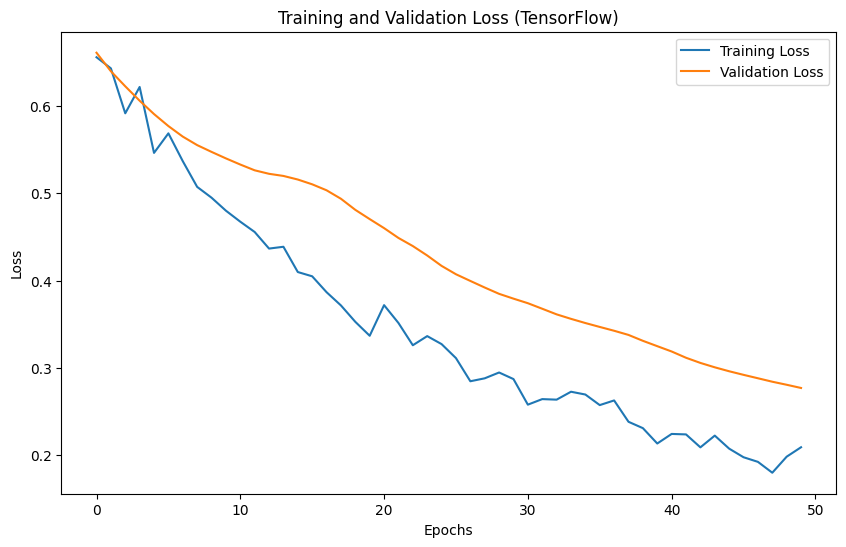

In [15]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (TensorFlow)')
plt.legend()
plt.show()

#assignment

In [16]:
# Fill missing numerical values with median
df['BMI'].fillna(df['BMI'].median(), inplace=True)

# Fill missing categorical values with mode
for col in ['Family History of Diabetes', 'Smoking', 'Diet', 'Exercise']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

label_cols = ['Gender', 'Blood Pressure', 'Family History of Diabetes',
              'Smoking', 'Diet', 'Exercise', 'Diagnosis']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

df.head()


/tmp/ipython-input-16-2867401591.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BMI'].fillna(df['BMI'].median(), inplace=True)
/tmp/ipython-input-16-2867401591.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,1,25.0,2,100,5.7,0,0,0,1,0
1,55,0,30.0,0,120,6.4,1,1,1,0,1
2,65,1,35.0,0,140,7.1,1,1,1,0,1
3,75,0,40.0,0,160,7.8,1,1,1,0,1
5,50,0,25.0,2,100,5.7,0,0,0,1,0


In [17]:
from imblearn.over_sampling import SMOTE

X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

In [19]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(50, 25), activation='relu', solver='adam',
                    max_iter=500, random_state=42)

mlp.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



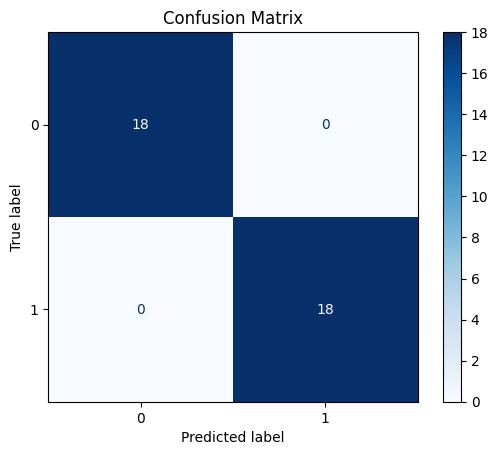

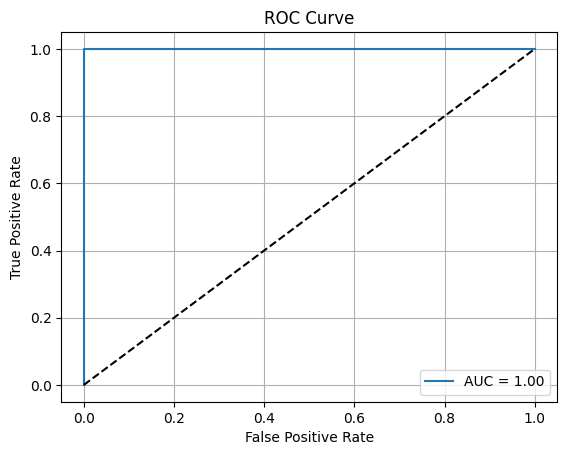

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Classification Report
y_pred = mlp.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
y_proba = mlp.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
#Install PyTorch from here: https://pytorch.org/get-started/locally/ (select compute platform as cpu if you dont have a gpu or doesn't have gpu drivers installed)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

CNN using tensorflow

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
from warnings import filterwarnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
filterwarnings("ignore")

In [35]:
# Download and Load the dataset into python workspace
#We are using MNIST dataset, it contains images of digits(from 0-9) and their labels
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import load_model

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [36]:
# Understand And Organize the Dataset
# Check data types
print(f"x_train data type: {type(x_train)}")
print(f"y_train data type: {type(y_train)}")
print(f"x_test data type: {type(x_test)}")
print(f"y_test data type: {type(y_test)}\n")

# Check shapes of the datasets
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

# Check unique values in target variables
print(f"Unique values in y_train: {np.unique(y_train)}")
print(f"Unique values in y_test: {np.unique(y_test)}\n")

# Check if there is any missing data
print(f"Any missing values in x_train: {np.any(np.isnan(x_train))}")
print(f"Any missing values in y_train: {np.any(np.isnan(y_train))}")
print(f"Any missing values in x_test: {np.any(np.isnan(x_test))}")
print(f"Any missing values in y_test: {np.any(np.isnan(y_test))}")

x_train data type: <class 'numpy.ndarray'>
y_train data type: <class 'numpy.ndarray'>
x_test data type: <class 'numpy.ndarray'>
y_test data type: <class 'numpy.ndarray'>

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)

Unique values in y_train: [0 1 2 3 4 5 6 7 8 9]
Unique values in y_test: [0 1 2 3 4 5 6 7 8 9]

Any missing values in x_train: False
Any missing values in y_train: False
Any missing values in x_test: False
Any missing values in y_test: False


In [37]:
# How many different label values do we have?

num_labels = len(np.unique(y_train))
num_labels

10

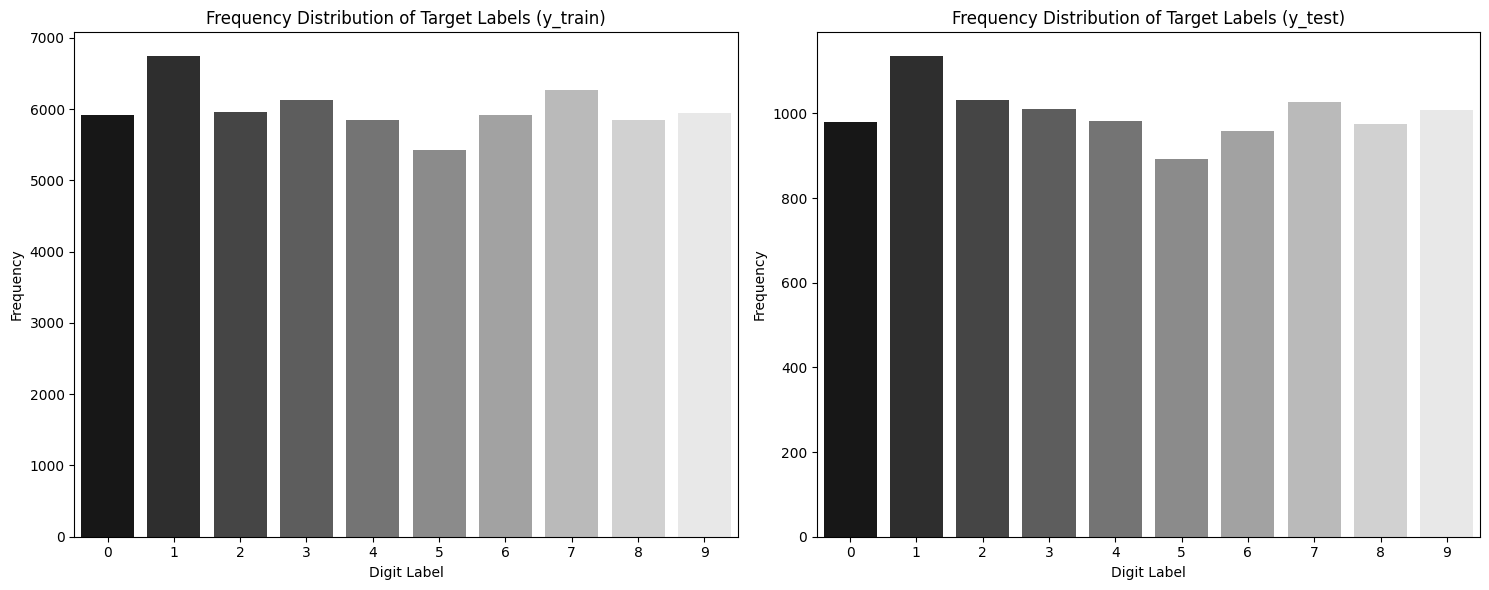

In [38]:
# Frequency Distribution of Target Labels y_train and y_test

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(x=y_train, palette='gray', ax=axes[0])
axes[0].set_title('Frequency Distribution of Target Labels (y_train)')
axes[0].set_xlabel('Digit Label')
axes[0].set_ylabel('Frequency')

sns.countplot(x=y_test, palette='gray', ax=axes[1])
axes[1].set_title('Frequency Distribution of Target Labels (y_test)')
axes[1].set_xlabel('Digit Label')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

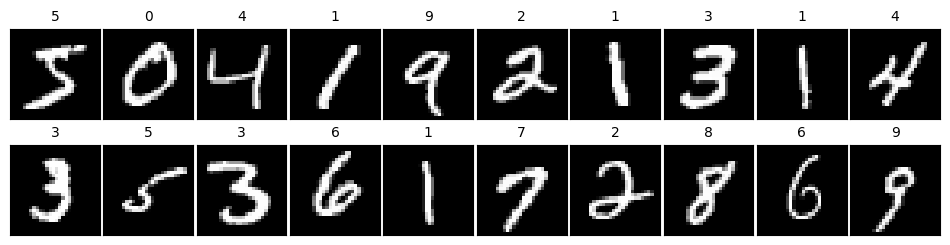

In [39]:
# Visualization of Some Digits and Their Labels

def visualize_images(data):
    fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(12,3),
                             gridspec_kw={'wspace':0.04, 'hspace':0.01},
                             squeeze=True)

    for i, ax in enumerate(axes.flat):
        ax.imshow(x_train[i], cmap='gray')
        ax.set_xticks([]), ax.set_yticks([])
        ax.set_title(str(y_train[i]), fontsize=10)

    plt.tight_layout()
    plt.show()

visualize_images(x_train)

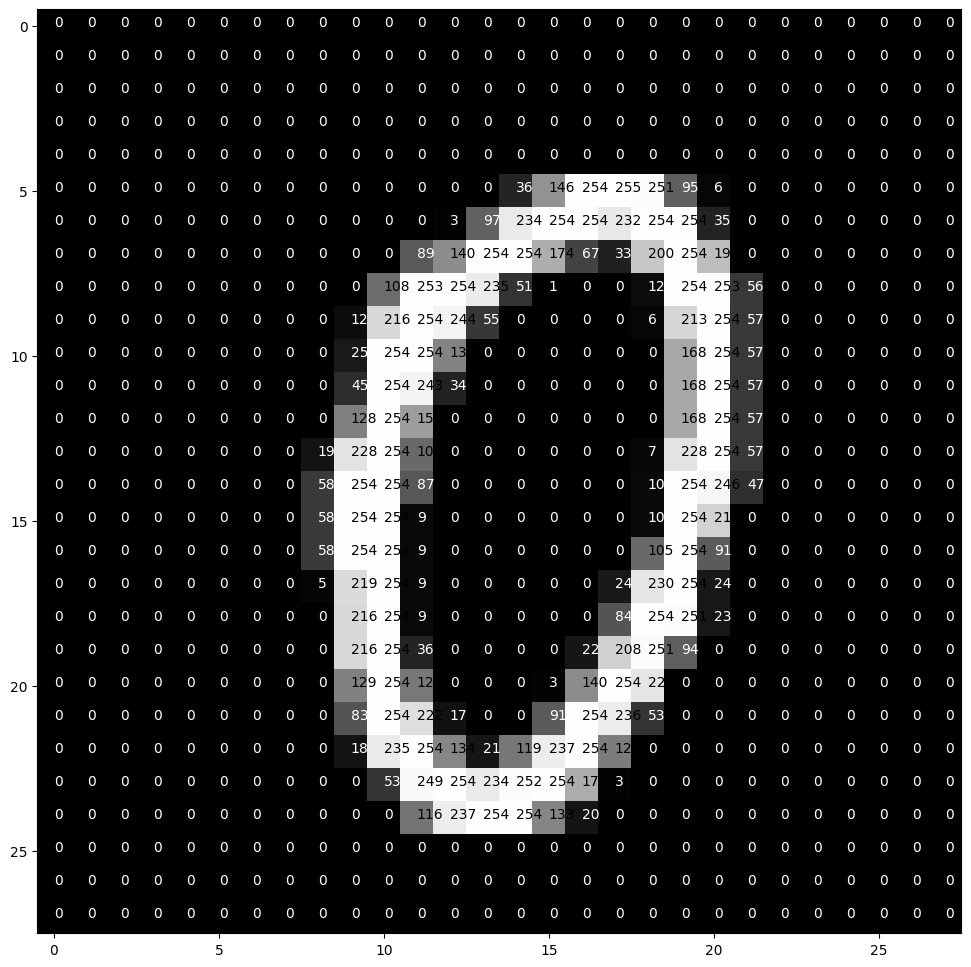

In [40]:
# Visualizing an Image with Pixel Values

def pixel_visualize(img):
    fig = plt.figure(figsize=(12,12))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap="gray")
    width, height = img.shape
    threshold = img.max()/2.5
    for x in range(width):
        for y in range(height):
            ax.annotate(str(round(img[x][y], 2)), xy=(y,x),
                       color='white' if img [x][y]<threshold else 'black')

pixel_visualize(x_train[1000])

In [41]:
# Preprocessing
#print few labels
y_train[0:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

In [42]:
#apply one hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [43]:
y_train[0:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [44]:
#lets take a look at shape of our dataset
x_train.shape

(60000, 28, 28)

In [45]:
#add a third dimension(it represents channels in the image, which tells the cnn if image is grayscale(1 channel) or colored (3 channels: rgb))
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


In [46]:
#normalizing the values of pixels in the x_train and x_test
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

In [47]:
# Model Building/Designing

model = Sequential()

model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=x_train.shape[1:]))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(num_labels, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001),
             loss='categorical_crossentropy',
             metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), "accuracy"])

In [48]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       819,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 892,266 (3.40 MB)

 Trainable params: 891,050 (3.40 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [49]:
# Using ImageDataGenerator for Data Augmentation: This step increases the sample size of dataset, to help counter overfitting

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=False,
    fill_mode='nearest'
)
datagen.fit(x_train)

In [50]:
# Training the model

early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)#using earlystopping
history = model.fit(datagen.flow(x_train, y_train, batch_size=512), epochs=5,
                    validation_data=(x_test, y_test), callbacks=[early_stopping])

Epoch 1/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.5569 - loss: 1.5661 - precision: 0.6337 - recall: 0.4930 - val_accuracy: 0.1135 - val_loss: 4.3120 - val_precision: 0.1135 - val_recall: 0.1135
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.8955 - loss: 0.3310 - precision: 0.9191 - recall: 0.8771 - val_accuracy: 0.1179 - val_loss: 4.3628 - val_precision: 0.1166 - val_recall: 0.1145
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.9328 - loss: 0.2196 - precision: 0.9469 - recall: 0.9219 - val_accuracy: 0.2766 - val_loss: 2.4957 - val_precision: 0.3353 - val_recall: 0.2546
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.9509 - loss: 0.1596 - precision: 0.9600 - recall: 0.9429 - val_accuracy: 0.8722 - val_loss: 0.4309 - val_precision: 0.9498 - val_recall: 0.7973
Epoch 5/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.9557 - loss: 0.1412 - precision: 0.9641 - recall: 0.9501 - val_accuracy: 0.9708 - val_loss: 0.

In [51]:
# Results and Visualization of the Model

y_pred = model.predict(x_test)
y_pred_class = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step


In [52]:
# Classification Report

class_labels = ['0','1','2','3','4','5','6','7','8','9']
report = classification_report(y_true, y_pred_class, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.89      1.00      0.94      1010
           4       0.98      0.97      0.98       982
           5       0.99      0.91      0.95       892
           6       1.00      0.92      0.96       958
           7       0.98      1.00      0.99      1028
           8       0.94      0.98      0.96       974
           9       0.96      0.99      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



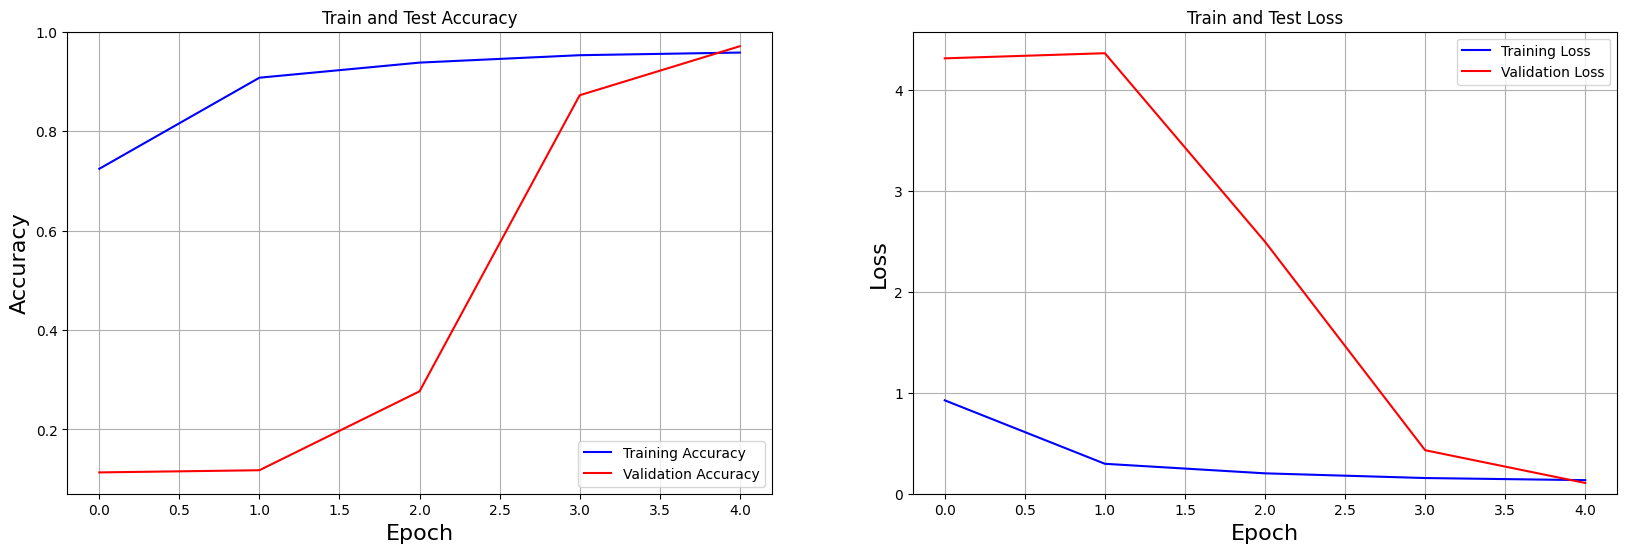

In [53]:
# Train & Test Accuracy and Loss

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], color='b', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='r', label='Validation Accuracy')
plt.legend()
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.ylim([min(plt.ylim()),1])
plt.title('Train and Test Accuracy')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['loss'], color='b', label='Training Loss')
plt.plot(history.history['val_loss'], color='r', label='Validation Loss')
plt.legend()
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.ylim([0,max(plt.ylim())])
plt.title('Train and Test Loss')
plt.grid(True)
plt.show()

In [54]:
#evaluating the model using common metrics
loss, precision, recall, acc=model.evaluate(x_test, y_test, verbose=False)
print('Test Accuracy: ', acc)
print('Test Loss: ', loss)
print('Test Precision: ', precision)
print('Test Recall: ', recall)

Test Accuracy:  0.97079998254776
Test Loss:  0.10631047189235687
Test Precision:  0.9775075912475586
Test Recall:  0.9648000001907349


In [55]:
# Testing Results

import random
random = random.randint(0, x_test.shape[0])
random

982

In [56]:
test_image = x_test[random]
y_test[random]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

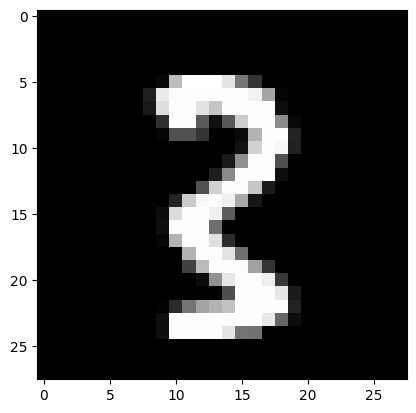

In [57]:
plt.imshow(test_image.reshape(28,28), cmap='gray');

In [58]:
test_data = x_test[random].reshape(1,28,28,1)
probability = model.predict(test_data)
probability

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


array([[1.9120941e-08, 5.4990305e-06, 2.7028202e-05, 9.9990678e-01,
        6.5951937e-08, 6.1150909e-06, 9.9163904e-09, 3.8538405e-05,
        1.2120416e-05, 3.8217513e-06]], dtype=float32)

In [59]:
predicted_classes = np.argmax(probability)
predicted_classes

np.int64(3)

In [60]:
print(f'Predicted class: {predicted_classes}')
print(f'Predicted class probability value: {(np.argmax(probability, axis=-1))[0]}')
print(f'Probability values of other classes: \n{probability}')

Predicted class: 3
Predicted class probability value: 3
Probability values of other classes: 
[[1.9120941e-08 5.4990305e-06 2.7028202e-05 9.9990678e-01 6.5951937e-08
  6.1150909e-06 9.9163904e-09 3.8538405e-05 1.2120416e-05 3.8217513e-06]]


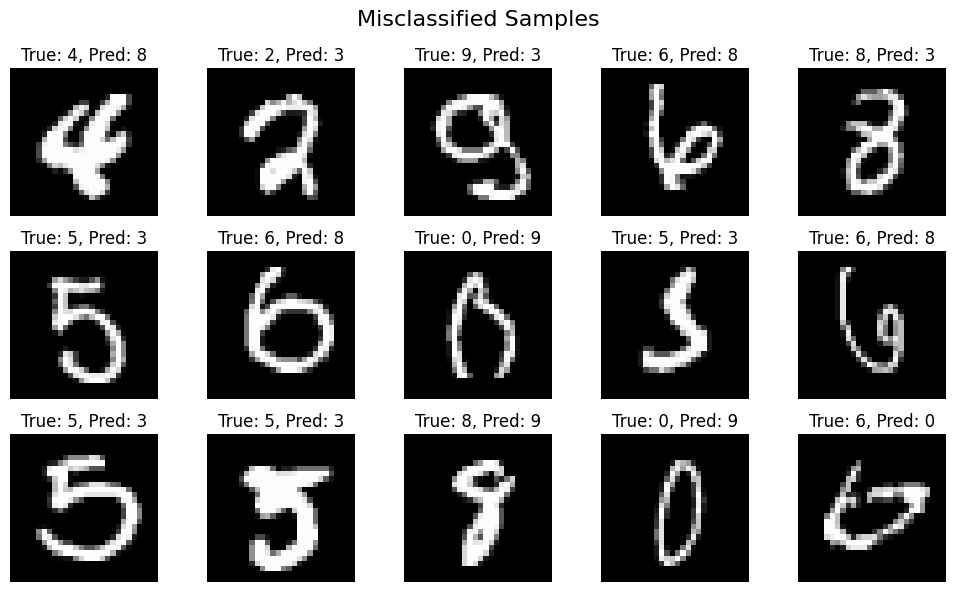

In [61]:
# Misclassified Samples

y_test_labels = np.argmax(y_test, axis=1)

misclassified_idx = np.where(y_pred_class != y_test_labels)[0]

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
fig.suptitle("Misclassified Samples", fontsize=16)

for i, ax in enumerate(axes.flat):
    idx = misclassified_idx[i]
    ax.imshow(x_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"True: {y_test_labels[idx]}, Pred: {y_pred_class[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

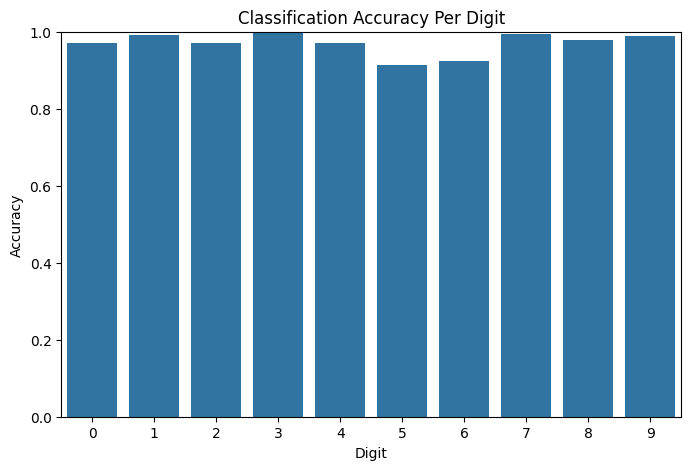

In [62]:
# Classification Accuracy Per Digit

num_classes = 10
class_accuracies = []

for i in range(num_classes):
    correct = np.sum((y_test_labels == i) & (y_pred_class == i))
    total = np.sum(y_test_labels == i)
    accuracy = correct / total if total > 0 else 0
    class_accuracies.append(accuracy)

df = pd.DataFrame({"Digit": range(10), "Accuracy": class_accuracies})

plt.figure(figsize=(8, 5))
sns.barplot(x="Digit", y="Accuracy", data=df)
plt.ylim(0, 1)
plt.xlabel("Digit")
plt.ylabel("Accuracy")
plt.title("Classification Accuracy Per Digit")
plt.show()

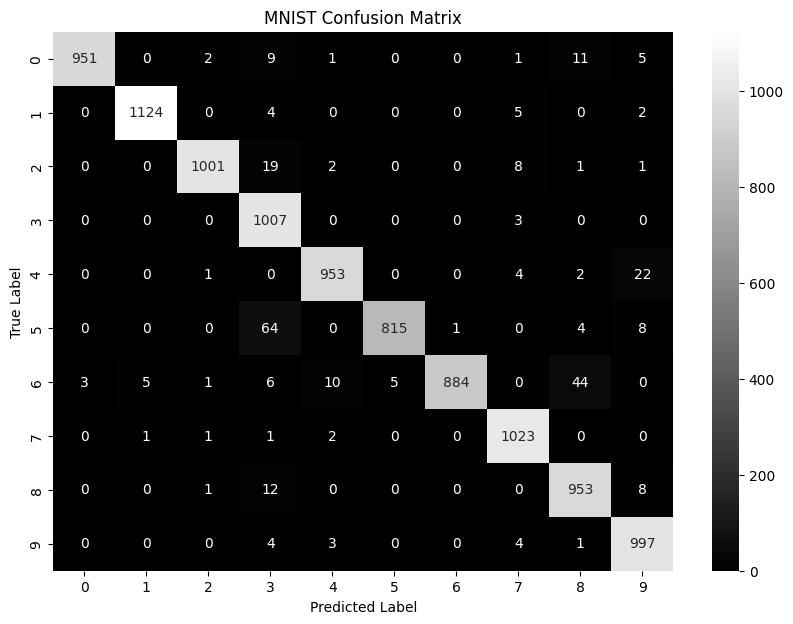

In [63]:
# Confusion Matrix

y_pred_labels = y_pred_class
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="gray", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MNIST Confusion Matrix")
plt.show()

CNN using Pytorch

In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [65]:
# Define transformations: Convert images to tensors and normalize them
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize pixel values to [-1, 1]
])

# Download and load the training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)

# Download and load the test dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 41.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.89MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 12.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.57MB/s]


In [66]:
# Define batch size
batch_size = 64

# Create DataLoaders for training and testing
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

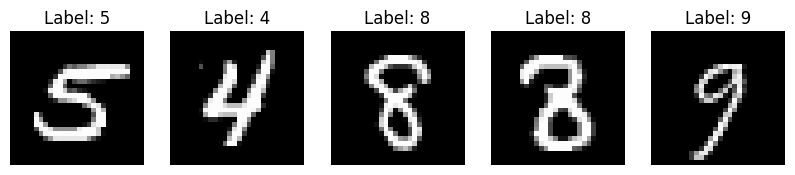

In [67]:
# Visualize Some Samples

# Function to display images
def show_images(images, labels):
    images = images.numpy()  # Convert tensors to numpy arrays
    fig, axes = plt.subplots(1, len(images), figsize=(10, 2))

    for i, ax in enumerate(axes):
        ax.imshow(images[i].squeeze(), cmap='gray')  # Remove color channel for grayscale images
        ax.set_title(f'Label: {labels[i].item()}')
        ax.axis('off')

# Get a batch of images from the train_loader
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Show first 5 images
show_images(images[:5], labels[:5])
plt.show()

In [68]:
# Define the Neural Network Model

class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()

        # Fully connected layers
        self.fc1 = nn.Linear(28*28, 128)  # Input layer → Hidden layer 1
        self.fc2 = nn.Linear(128, 64)     # Hidden layer 1 → Hidden layer 2
        self.fc3 = nn.Linear(64, 10)      # Hidden layer 2 → Output layer

        # Define Leaky ReLU with negative slope (default is 0.01)
        self.leaky_relu = nn.LeakyReLU(negative_slope=0.01)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the image to (batch_size, 784)
        x = self.leaky_relu(self.fc1(x))  # Leaky ReLU for hidden layer 1
        x = self.leaky_relu(self.fc2(x))  # Leaky ReLU for hidden layer 2
        x = self.fc3(x)  # Output logits (no activation, since we use CrossEntropyLoss)
        return x

# Create model instance
model = NeuralNet()
print(model)  # Display model architecture

NeuralNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (leaky_relu): LeakyReLU(negative_slope=0.01)
)


In [69]:
# Define the loss function (Cross-Entropy for classification tasks)
criterion = nn.CrossEntropyLoss()

# Define the optimizer (Stochastic Gradient Descent)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print("Loss function and optimizer initialized!")

Loss function and optimizer initialized!


In [70]:
# Train the Model
num_epochs = 10  # Number of times the model sees the entire dataset

for epoch in range(num_epochs):  # Loop through the dataset multiple times
    running_loss = 0.0  # Track loss per epoch

    for images, labels in train_loader:
        # 1. Zero the gradient buffers
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(images)

        # 3. Compute loss
        loss = criterion(outputs, labels)

        # 4. Backward pass (compute gradients)
        loss.backward()

        # 5. Update weights
        optimizer.step()

        # 6. Accumulate loss
        running_loss += loss.item()

    # Print loss after each epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

print("Training complete!")

Epoch [1/10], Loss: 0.4184
Epoch [2/10], Loss: 0.1707
Epoch [3/10], Loss: 0.1269
Epoch [4/10], Loss: 0.1036
Epoch [5/10], Loss: 0.0863
Epoch [6/10], Loss: 0.0738
Epoch [7/10], Loss: 0.0650
Epoch [8/10], Loss: 0.0568
Epoch [9/10], Loss: 0.0514
Epoch [10/10], Loss: 0.0454
Training complete!


In [71]:
## Evaluate the Model

correct = 0
total = 0

# Disable gradient computation for evaluation (faster and memory-efficient)
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)  # Forward pass
        _, predicted = torch.max(outputs, 1)  # Get class with highest probability
        total += labels.size(0)  # Total test samples
        correct += (predicted == labels).sum().item()  # Count correct predictions

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.33%


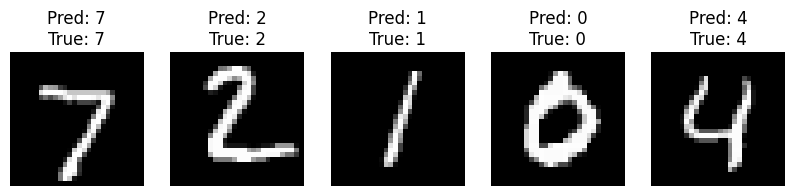

In [72]:
# Display Predictions on Sample Images
# Get a batch of test images
data_iter = iter(test_loader)
images, labels = next(data_iter)

# Get model predictions
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Function to display images with predicted labels
def show_predictions(images, labels, predicted):
    images = images.numpy()
    fig, axes = plt.subplots(1, 5, figsize=(10, 2))

    for i, ax in enumerate(axes):
        ax.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title(f'Pred: {predicted[i].item()}\nTrue: {labels[i].item()}')
        ax.axis('off')

# Show the first 5 test images with predictions
show_predictions(images[:5], labels[:5], predicted[:5])
plt.show()